# Notebook 04 — Rule Engine Development & Validation
**Goal:** Implement, test, và validate 6+ AML rules theo PRD FR-01.

> Historical prototype note: this notebook contains a standalone PaySim rule-engine sketch with notebook-local context names such as `new_balance_orig`. The backend runtime rule engine is `backend/app/rules/engine.py`, and the backend-compatible YAML is `ml/rules/aml_rules.yaml` / `configs/rules.yaml` using whitelisted feature names from `ALLOWED_CONTEXT_NAMES`.

**Rules cần implement:**
1. `RULE_STRUCTURING` — Chia nhỏ giao dịch sát ngưỡng báo cáo
2. `RULE_THRESHOLD_AVOIDANCE` — Giao dịch đơn lẻ sát dưới ngưỡng
3. `RULE_RAPID_MOVEMENT` — Tiền vào và ra trong 1h
4. `RULE_HIGH_VELOCITY` — Khối lượng giao dịch cao bất thường
5. `RULE_ZERO_BALANCE_DRAIN` — Tài khoản bị rút cạn
6. `RULE_LAYERING` — Chuỗi giao dịch trung gian
7. `RULE_LARGE_CASHOUT` — Rút tiền lớn

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yaml
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional

sns.set_theme(style='whitegrid')
DATA_PATH = '../paysim dataset.csv'
RULES_PATH = '../rules/aml_rules.yaml'

## 1. Rule Engine Implementation

In [2]:
@dataclass
class RuleResult:
    rule_id: str
    triggered: bool
    severity: str
    action: str
    reason: str = ''

@dataclass
class TransactionContext:
    """Enriched transaction with computed features for rule evaluation."""
    transaction_id: str
    step: int
    type: str
    amount: float
    sender_id: str
    receiver_id: str
    old_balance_orig: float
    new_balance_orig: float
    old_balance_dest: float
    new_balance_dest: float
    # Computed features
    tx_count_24h: int = 0
    total_amount_24h: float = 0.0
    min_amount_24h: float = 0.0
    max_amount_24h: float = 0.0
    baseline_tx_count: float = 1.0
    time_since_last_receipt_minutes: Optional[float] = None
    last_received_amount: float = 0.0
    dest_resent_ratio: float = 0.0
    chain_depth: int = 0

class AMLRuleEngine:
    CTR_THRESHOLD = 200_000  # PaySim units (simulate VND threshold)
    
    def __init__(self, rules_path: str):
        with open(rules_path) as f:
            config = yaml.safe_load(f)
        self.rules = {r['id']: r for r in config['rules']}
        self.thresholds = config['thresholds']
    
    def evaluate(self, ctx: TransactionContext) -> List[RuleResult]:
        results = []
        for rule_id, rule in self.rules.items():
            method = getattr(self, f'_check_{rule["pattern"]}', None)
            if method:
                result = method(ctx, rule)
                results.append(result)
        return results
    
    def get_triggered(self, ctx: TransactionContext) -> List[RuleResult]:
        return [r for r in self.evaluate(ctx) if r.triggered]
    
    def _check_structuring(self, ctx, rule) -> RuleResult:
        triggered = (
            ctx.tx_count_24h >= 3 and
            ctx.min_amount_24h >= self.CTR_THRESHOLD * 0.80 and
            ctx.max_amount_24h < self.CTR_THRESHOLD and
            ctx.total_amount_24h >= self.CTR_THRESHOLD * 2
        )
        return RuleResult(
            rule_id=rule['id'], triggered=triggered,
            severity=rule['severity'], action=rule['action'],
            reason=f'Structuring: {ctx.tx_count_24h} txs in 24h, total {ctx.total_amount_24h:.0f}'
        )
    
    def _check_threshold_avoidance(self, ctx, rule) -> RuleResult:
        triggered = self.CTR_THRESHOLD * 0.90 <= ctx.amount < self.CTR_THRESHOLD
        return RuleResult(
            rule_id=rule['id'], triggered=triggered,
            severity=rule['severity'], action=rule['action'],
            reason=f'Amount {ctx.amount:.0f} is {ctx.amount/self.CTR_THRESHOLD*100:.1f}% of threshold'
        )
    
    def _check_rapid_movement(self, ctx, rule) -> RuleResult:
        triggered = (
            ctx.time_since_last_receipt_minutes is not None and
            ctx.time_since_last_receipt_minutes <= 60 and
            ctx.amount >= ctx.last_received_amount * 0.9 and
            ctx.type in ('TRANSFER', 'CASH_OUT')
        )
        mins = ctx.time_since_last_receipt_minutes or 0
        return RuleResult(
            rule_id=rule['id'], triggered=triggered,
            severity=rule['severity'], action=rule['action'],
            reason=f'Rapid movement: received {ctx.last_received_amount:.0f} {mins:.0f}min ago'
        )
    
    def _check_velocity_anomaly(self, ctx, rule) -> RuleResult:
        ratio = ctx.tx_count_24h / max(ctx.baseline_tx_count, 1)
        triggered = ratio >= 10
        return RuleResult(
            rule_id=rule['id'], triggered=triggered,
            severity=rule['severity'], action=rule['action'],
            reason=f'Velocity {ratio:.1f}x baseline ({ctx.tx_count_24h} vs {ctx.baseline_tx_count:.1f} baseline)'
        )
    
    def _check_account_drain(self, ctx, rule) -> RuleResult:
        triggered = (
            ctx.new_balance_orig <= 0 and
            ctx.amount >= 100_000 and
            ctx.type in ('CASH_OUT', 'TRANSFER')
        )
        return RuleResult(
            rule_id=rule['id'], triggered=triggered,
            severity=rule['severity'], action=rule['action'],
            reason=f'Account fully drained: {ctx.old_balance_orig:.0f} → {ctx.new_balance_orig:.0f}'
        )
    
    def _check_layering(self, ctx, rule) -> RuleResult:
        triggered = (
            ctx.dest_resent_ratio >= 0.8 and
            ctx.chain_depth >= 2
        )
        return RuleResult(
            rule_id=rule['id'], triggered=triggered,
            severity=rule['severity'], action=rule['action'],
            reason=f'Layering: chain depth {ctx.chain_depth}, dest resent {ctx.dest_resent_ratio:.0%}'
        )
    
    def _check_large_transaction(self, ctx, rule) -> RuleResult:
        triggered = (
            ctx.amount >= self.CTR_THRESHOLD and
            ctx.type in ('CASH_OUT', 'TRANSFER')
        )
        return RuleResult(
            rule_id=rule['id'], triggered=triggered,
            severity=rule['severity'], action=rule['action'],
            reason=f'Large {ctx.type}: {ctx.amount:.0f} (threshold {self.CTR_THRESHOLD:,})'
        )

engine = AMLRuleEngine(RULES_PATH)
print(f'Loaded {len(engine.rules)} rules')
for rule_id, rule in engine.rules.items():
    print(f'  {rule_id}: {rule["name"]} ({rule["severity"]}')

Loaded 7 rules
  RULE_STRUCTURING: Structuring / Smurfing (HIGH
  RULE_THRESHOLD_AVOIDANCE: Threshold Avoidance (MEDIUM
  RULE_RAPID_MOVEMENT: Rapid Movement (HIGH
  RULE_HIGH_VELOCITY: High Velocity (HIGH
  RULE_ZERO_BALANCE_DRAIN: Zero Balance Drain (HIGH
  RULE_LAYERING: Layering Chain (HIGH
  RULE_LARGE_CASHOUT: Large Cash Out (MEDIUM


## 2. Rule Smoke Test

In [3]:
# Test case 1: Structuring transaction
ctx_structuring = TransactionContext(
    transaction_id='TX001', step=100, type='TRANSFER',
    amount=185_000, sender_id='C001', receiver_id='C002',
    old_balance_orig=1_000_000, new_balance_orig=815_000,
    old_balance_dest=0, new_balance_dest=185_000,
    tx_count_24h=5, total_amount_24h=920_000,
    min_amount_24h=175_000, max_amount_24h=195_000,
    baseline_tx_count=1.0
)

# Test case 2: Clean transaction
ctx_clean = TransactionContext(
    transaction_id='TX002', step=200, type='PAYMENT',
    amount=5_000, sender_id='C003', receiver_id='M001',
    old_balance_orig=50_000, new_balance_orig=45_000,
    old_balance_dest=0, new_balance_dest=0,
    tx_count_24h=1, total_amount_24h=5_000,
    min_amount_24h=5_000, max_amount_24h=5_000,
    baseline_tx_count=1.2
)

# Test case 3: Account drain
ctx_drain = TransactionContext(
    transaction_id='TX003', step=300, type='CASH_OUT',
    amount=500_000, sender_id='C004', receiver_id='C005',
    old_balance_orig=500_000, new_balance_orig=0,
    old_balance_dest=0, new_balance_dest=500_000,
    tx_count_24h=1, total_amount_24h=500_000,
    min_amount_24h=500_000, max_amount_24h=500_000,
    baseline_tx_count=1.0
)

for name, ctx in [('Structuring', ctx_structuring), ('Clean', ctx_clean), ('Account Drain', ctx_drain)]:
    triggered = engine.get_triggered(ctx)
    print(f'\n--- {name} ---')
    if triggered:
        for r in triggered:
            print(f'  TRIGGERED: {r.rule_id} [{r.severity}] — {r.reason}')
    else:
        print('  No rules triggered — CLEAN')


--- Structuring ---
  TRIGGERED: RULE_STRUCTURING [HIGH] — Structuring: 5 txs in 24h, total 920000
  TRIGGERED: RULE_THRESHOLD_AVOIDANCE [MEDIUM] — Amount 185000 is 92.5% of threshold

--- Clean ---
  No rules triggered — CLEAN

--- Account Drain ---
  TRIGGERED: RULE_ZERO_BALANCE_DRAIN [HIGH] — Account fully drained: 500000 → 0
  TRIGGERED: RULE_LARGE_CASHOUT [MEDIUM] — Large CASH_OUT: 500000 (threshold 200,000)


## 3. Rule Validation on PaySim Dataset

In [4]:
dtype_map = {
    'step': 'int16', 'type': 'category', 'amount': 'float32',
    'nameOrig': 'str', 'oldbalanceOrg': 'float32', 'newbalanceOrig': 'float32',
    'nameDest': 'str', 'oldbalanceDest': 'float32', 'newbalanceDest': 'float32',
    'isFraud': 'int8', 'isFlaggedFraud': 'int8',
}
df = pd.read_csv(DATA_PATH, dtype=dtype_map)

# Apply rules vectorized on entire dataset
CTR = engine.CTR_THRESHOLD

# Rule: Threshold Avoidance (vectorized)
df['rule_threshold_avoid'] = (
    (df['amount'] >= CTR * 0.90) & (df['amount'] < CTR)
).astype('int8')

# Rule: Large CASHOUT/TRANSFER
df['rule_large_cashout'] = (
    (df['amount'] >= CTR) & (df['type'].isin(['CASH_OUT', 'TRANSFER']))
).astype('int8')

# Rule: Zero Balance Drain
df['rule_balance_drain'] = (
    (df['newbalanceOrig'] <= 0) &
    (df['amount'] >= 100_000) &
    (df['type'].isin(['CASH_OUT', 'TRANSFER']))
).astype('int8')

# Balance inconsistency (layering signal)
df['rule_balance_inconsist'] = (
    ((df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']).abs() > 1)
).astype('int8')

rule_cols = [c for c in df.columns if c.startswith('rule_')]
print('=== Rule Coverage Analysis ===')
print(f'Total transactions: {len(df):,}')
print(f'Fraud transactions: {df["isFraud"].sum():,}\n')

stats = []
for col in rule_cols:
    flagged = df[df[col]==1]
    total_flagged = len(flagged)
    fraud_flagged = flagged['isFraud'].sum()
    fraud_rate = fraud_flagged / total_flagged if total_flagged > 0 else 0
    fp_rate = (total_flagged - fraud_flagged) / (df['isFraud']==0).sum()
    recall = fraud_flagged / df['isFraud'].sum() if df['isFraud'].sum() > 0 else 0
    stats.append({
        'rule': col, 'flagged': total_flagged, 'fraud_caught': fraud_flagged,
        'precision': fraud_rate, 'recall': recall, 'fpr': fp_rate
    })
    print(f'{col}:')
    print(f'  Flagged: {total_flagged:,} | Fraud caught: {fraud_flagged:,}')
    print(f'  Precision: {fraud_rate:.4f} | Recall: {recall:.4f} | FPR: {fp_rate:.4f}')

df_stats = pd.DataFrame(stats)

=== Rule Coverage Analysis ===
Total transactions: 6,362,620
Fraud transactions: 8,213

rule_threshold_avoid:
  Flagged: 201,321 | Fraud caught: 129
  Precision: 0.0006 | Recall: 0.0157 | FPR: 0.0317


rule_large_cashout:
  Flagged: 1,197,669 | Fraud caught: 5,471
  Precision: 0.0046 | Recall: 0.6661 | FPR: 0.1876


rule_balance_drain:
  Flagged: 1,840,494 | Fraud caught: 6,347
  Precision: 0.0034 | Recall: 0.7728 | FPR: 0.2886


rule_balance_inconsist:
  Flagged: 5,000,803 | Fraud caught: 51
  Precision: 0.0000 | Recall: 0.0062 | FPR: 0.7870


## 4. Rule Performance Visualization

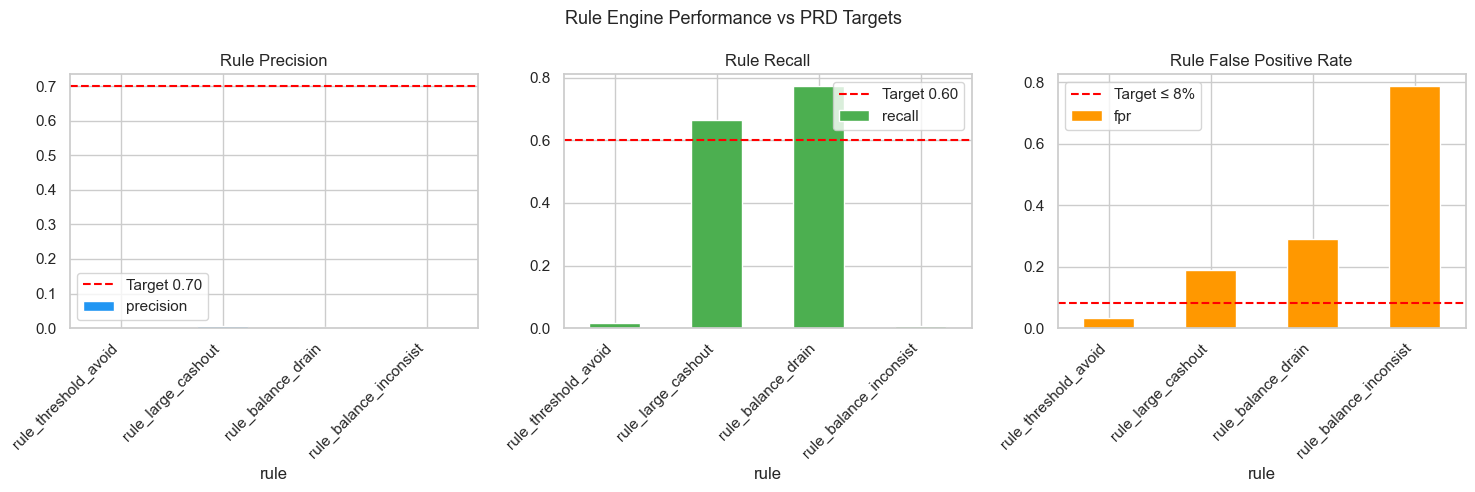


=== PRD Compliance Check ===
rule_threshold_avoid: FPR=0.0317 ✓
rule_large_cashout: FPR=0.1876 ✗
rule_balance_drain: FPR=0.2886 ✗
rule_balance_inconsist: FPR=0.7870 ✗


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_stats.plot(kind='bar', x='rule', y='precision', ax=axes[0], legend=False, color='#2196F3')
axes[0].axhline(0.70, color='red', linestyle='--', label='Target 0.70')
axes[0].set_title('Rule Precision')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend()

df_stats.plot(kind='bar', x='rule', y='recall', ax=axes[1], legend=False, color='#4CAF50')
axes[1].axhline(0.60, color='red', linestyle='--', label='Target 0.60')
axes[1].set_title('Rule Recall')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend()

df_stats.plot(kind='bar', x='rule', y='fpr', ax=axes[2], legend=False, color='#FF9800')
axes[2].axhline(0.08, color='red', linestyle='--', label='Target ≤ 8%')
axes[2].set_title('Rule False Positive Rate')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].legend()

plt.suptitle('Rule Engine Performance vs PRD Targets', fontsize=13)
plt.tight_layout()
plt.show()

# PRD requirement: FPR ≤ 8% per rule
print('\n=== PRD Compliance Check ===')
for _, row in df_stats.iterrows():
    fpr_ok = '✓' if row['fpr'] <= 0.08 else '✗'
    print(f'{row["rule"]}: FPR={row["fpr"]:.4f} {fpr_ok}')

## 5. Combined Rule + ML Decision Logic

In [6]:
# PRD R5 mitigation: define clear combination rules
print("""
=== DECISION LOGIC (PRD §R5 Mitigation) ===

Priority order:
1. If any RULE fires with severity=HIGH → decision = FLAG (override ML)
2. If ML risk_score >= 0.85 → decision = BLOCK
3. If ML risk_score >= threshold_flag → decision = FLAG
4. Else → decision = ALLOW

Rule fires always elevate to FLAG minimum.
ML score used for ranking/prioritization within FLAG tier.
""")

def combine_decision(rule_results: list, ml_score: float,
                     threshold_flag: float = 0.5, threshold_block: float = 0.85) -> dict:
    triggered_rules = [r for r in rule_results if r.triggered]
    high_severity_rules = [r for r in triggered_rules if r.severity == 'HIGH']
    
    if ml_score >= threshold_block:
        decision = 'BLOCK'
    elif high_severity_rules or ml_score >= threshold_flag:
        decision = 'FLAG'
    else:
        decision = 'ALLOW'
    
    return {
        'decision': decision,
        'risk_score': ml_score,
        'triggered_rules': [r.rule_id for r in triggered_rules],
        'rule_reasons': [r.reason for r in triggered_rules],
    }

# Test
mock_rules = engine.evaluate(ctx_structuring)
result = combine_decision(mock_rules, ml_score=0.72)
print('Test result for structuring case:')
print(json.dumps(result, indent=2))


=== DECISION LOGIC (PRD §R5 Mitigation) ===

Priority order:
1. If any RULE fires with severity=HIGH → decision = FLAG (override ML)
2. If ML risk_score >= 0.85 → decision = BLOCK
3. If ML risk_score >= threshold_flag → decision = FLAG
4. Else → decision = ALLOW

Rule fires always elevate to FLAG minimum.
ML score used for ranking/prioritization within FLAG tier.

Test result for structuring case:
{
  "decision": "FLAG",
  "risk_score": 0.72,
  "triggered_rules": [
    "RULE_STRUCTURING",
    "RULE_THRESHOLD_AVOIDANCE"
  ],
  "rule_reasons": [
    "Structuring: 5 txs in 24h, total 920000",
    "Amount 185000 is 92.5% of threshold"
  ]
}
